In [2]:
from jarvis.db.figshare import data
dft_3d = data("dft_3d")

Obtaining 3D dataset 76k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


In [12]:
from jarvis.core.atoms import Atoms
from pymatgen.core import Structure
from pymatgen.core.lattice import Lattice
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

len(dft_3d)

75993

In [13]:
#TC_SUPERCON    
tc_ = []
for i in dft_3d:
    if i["Tc_supercon"] != "na":
        atoms = Atoms.from_dict(i["atoms"])
        info = {}
        info["formula"] = atoms.composition.reduced_formula
        info["prop"] = round(i["Tc_supercon"], 3)
        info["lengths"] = atoms.lattice.abc
        info["angles"] = atoms.lattice.angles
        info["atom_ids"] = atoms.elements
        info["frac_coords"] = atoms.frac_coords
        tc_.append(info)

#optb88vdw_bandgap    
opt_ = []
for i in dft_3d:
    if i["optb88vdw_bandgap"] >= 0.0:
        atoms = Atoms.from_dict(i["atoms"])
        info = {}
        info["formula"] = atoms.composition.reduced_formula
        info["prop"] = round(i["optb88vdw_bandgap"], 3)
        info["lengths"] = atoms.lattice.abc
        info["angles"] = atoms.lattice.angles
        info["atom_ids"] = atoms.elements
        info["frac_coords"] = atoms.frac_coords
        opt_.append(info)

# #mbj_bandgap    
mbj_ = []
for i in dft_3d:
    if i["mbj_bandgap"] != "na" :
        atoms = Atoms.from_dict(i["atoms"])
        info = {}
        info["formula"] = atoms.composition.reduced_formula
        info["prop"] = round(i["mbj_bandgap"], 3)
        info["lengths"] = atoms.lattice.abc
        info["angles"] = atoms.lattice.angles
        info["atom_ids"] = atoms.elements
        info["frac_coords"] = atoms.frac_coords
        mbj_.append(info)

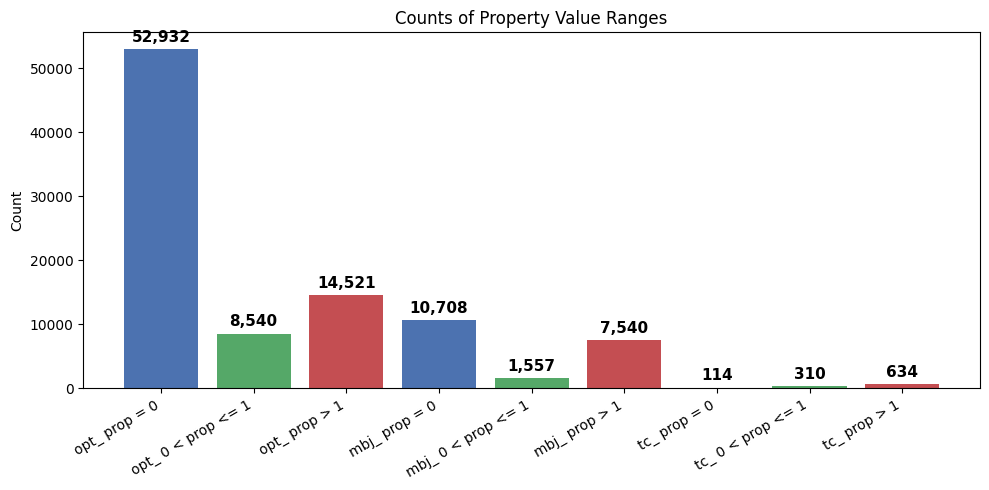

In [16]:
labels = [
    "opt_ prop = 0", "opt_ 0 < prop <= 1", "opt_ prop > 1",
    "mbj_ prop = 0", "mbj_ 0 < prop <= 1", "mbj_ prop > 1",
    "tc_ prop = 0", "tc_ 0 < prop <= 1", "tc_ prop > 1"
]

# opt_ splits
opt_eq_0 = sum(item["prop"] == 0 for item in opt_)
opt_0_1 = sum(0 < item["prop"] <= 1 for item in opt_)
opt_gt_1 = sum(item["prop"] > 1 for item in opt_)

# mbj_ splits
mbj_eq_0 = sum(item["prop"] == 0 for item in mbj_)
mbj_0_1 = sum(0 < item["prop"] <= 1 for item in mbj_)
mbj_gt_1 = sum(item["prop"] > 1 for item in mbj_)

# tc_ splits
tc_eq_0 = sum(item["prop"] == 0 for item in tc_)
tc_0_1 = sum(0 < item["prop"] <= 1 for item in tc_)
tc_gt_1 = sum(item["prop"] > 1 for item in tc_)

counts = [
    opt_eq_0, opt_0_1, opt_gt_1,
    mbj_eq_0, mbj_0_1, mbj_gt_1,
    tc_eq_0, tc_0_1, tc_gt_1
]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, counts, color=['#4C72B0', '#55A868', '#C44E52']*3)
plt.ylabel('Count')
plt.title('Counts of Property Value Ranges')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()


In [68]:
#read train and test data
from datasets import load_dataset

In [51]:
import re
def extract_formula_bandgap(text):
    """Extract chemical formula and MBJ bandgap from a prompt text.

    Returns a compact caption string like: "2 Fe 3 O 1.23" or the original text if parsing fails.
    """
    if not isinstance(text, str):
        return str(text)
    formula_match = re.search(r'The chemical formula is ([A-Za-z0-9]+)', text)
    bandgap_match = re.search(r'value is ([0-9.]+)', text)
    formula = formula_match.group(1) if formula_match else None
    bandgap_str = bandgap_match.group(1) if bandgap_match else None
    if bandgap_str:
        try:
            bandgap = float(bandgap_str.strip().rstrip('.'))
        except Exception:
            bandgap = None
    else:
        bandgap = None
    if formula is None and bandgap is None:
        return text
    
    # Parse the chemical formula to separate elements
    parsed_formula = formula if formula else ""
    return parsed_formula, bandgap


# TC SUPERCON COMPARISON

In [80]:
train_df = load_dataset('json', data_files='./data/alpaca_Tc_supercon_train.json')['train']
test_df = load_dataset('json', data_files='./data/alpaca_Tc_supercon_test.json')['train']

# Find matching (formula, bandgap) pairs
matching_pairs = train_pairs & test_pairs

# Compare the responses for each matching pair
for pair in matching_pairs:
    train_indices = [i for i, x in enumerate(train_df["input"]) if extract_formula_bandgap(x) == pair]
    test_indices = [i for i, x in enumerate(test_df["input"]) if extract_formula_bandgap(x) == pair]
    for ti in train_indices:
        for tei in test_indices:
            train_resp = train_df["response"][ti]
            test_resp = test_df["response"][tei]
            same = train_resp == test_resp
            print(f"Pair: {pair} | Train idx: {ti} | Test idx: {tei} | Same response: {same}")


Pair: ('AlCo', 0.0) | Train idx: 691 | Test idx: 15 | Same response: True
Pair: ('AlNi3', 0.0) | Train idx: 479 | Test idx: 85 | Same response: True
Pair: ('AlNi3', 0.0) | Train idx: 880 | Test idx: 85 | Same response: True
Pair: ('HfBe5', 1.094) | Train idx: 537 | Test idx: 37 | Same response: True
Pair: ('NaBePd2', 0.143) | Train idx: 160 | Test idx: 49 | Same response: True


In [82]:
len(train_df), len(test_df)

(952, 106)

# OPT BANDGAP COMPARISON

In [69]:
train_df = load_dataset('json', data_files='./data/alpaca_optb88vdw_bandgap_train.json')['train']
test_df = load_dataset('json', data_files='./data/alpaca_optb88vdw_bandgap_test.json')['train']

# Find matching (formula, bandgap) pairs
matching_pairs = train_pairs & test_pairs

# Compare the responses for each matching pair
for pair in matching_pairs:
    train_indices = [i for i, x in enumerate(train_df["input"]) if extract_formula_bandgap(x) == pair]
    test_indices = [i for i, x in enumerate(test_df["input"]) if extract_formula_bandgap(x) == pair]
    for ti in train_indices:
        for tei in test_indices:
            train_resp = train_df["response"][ti]
            test_resp = test_df["response"][tei]
            same = train_resp == test_resp
            print(f"Pair: {pair} | Train idx: {ti} | Test idx: {tei} | Same response: {same}")


# MBJ BANDGAP COMPARISON

In [79]:
train_df = load_dataset('json', data_files='./data/alpaca_mbj_bandgap_train.json')['train']
test_df = load_dataset('json', data_files='./data/alpaca_mbj_bandgap_test.json')['train']

# Find matching (formula, bandgap) pairs
matching_pairs = train_pairs & test_pairs

# Compare the responses for each matching pair
for pair in matching_pairs:
    train_indices = [i for i, x in enumerate(train_df["input"]) if extract_formula_bandgap(x) == pair]
    test_indices = [i for i, x in enumerate(test_df["input"]) if extract_formula_bandgap(x) == pair]
    for ti in train_indices:
        for tei in test_indices:
            train_resp = train_df["response"][ti]
            test_resp = test_df["response"][tei]
            same = train_resp == test_resp
            print(f"Pair: {pair} | Train idx: {ti} | Test idx: {tei} | Same response: {same}")
